---
title: "Network Analysis"
format:
    html:
        code-fold: false
---

## Introduction

This notebook synthesizes the data pipeline built in notebooks 01 through 03 and takes a first quantitative pass at the research questions from the mid-point presentation. The project studies food delivery in Washington, DC as a network problem. Two families of questions structure the work. The structural family asks where the road network breaks, meaning where the choke points are, which roads would repay renovation, and what restaurant clustering does to delivery. The operational family asks who should deliver and how, covering assignment strategies, peak load, robustness to closures, and fleet sizing.

The evidence base is the cleaned DC drive network with travel time weights, 2,043 snapped restaurant POIs, census tract population as a demand proxy, and observed 2024 AADT on the arterial skeleton. Where a question can be answered with simple and robust network statistics we answer it here. Where it requires the delivery simulation stage or data we do not have, we say so explicitly rather than stretch the evidence.

## Imports

In [1]:
import time
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import osmnx as ox
import pandas as pd
from scipy.stats import spearmanr

# paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CLEAN = PROJECT_ROOT / "data" / "clean"
OUTPUTS = PROJECT_ROOT / "outputs"

CRS_DC = "EPSG:26985"
RNG = np.random.default_rng(42)

# load clean data
G = ox.load_graphml(CLEAN / "dc_drive_clean.graphml")
pois = gpd.read_file(CLEAN / "dc_restaurants_clean.geojson")
tracts = gpd.read_file(CLEAN / "dc_tracts_clean.geojson")
node_tracts = pd.read_csv(CLEAN / "dc_nodes_tracts.csv")
edge_aadt = pd.read_csv(CLEAN / "dc_edge_aadt.csv")

nodes_gdf, edges_gdf = ox.graph_to_gdfs(G)
edges_p = edges_gdf.to_crs(CRS_DC)
print(f"Graph: {len(G.nodes):,} nodes, {len(G.edges):,} edges")

Graph: 10,027 nodes, 26,938 edges


## Data and Pipeline Summary

In [2]:
# what the pipeline produced across notebooks 01 to 03
rows = [
    {"Stage": "01 ingestion", "Asset": "OSM drive network, POIs, ACS tracts, AADT, ABCA licenses", "Result": "5 raw datasets for all of DC"},
    {"Stage": "02 cleaning", "Asset": "largest SCC, imputed speeds, snapped POIs, edge AADT, node-tract join", "Result": "10,027 nodes, 26,938 edges, 2,043 POIs, 206 tracts"},
    {"Stage": "03 EDA", "Asset": "7 high resolution figures in outputs", "Result": "clustering, demand mismatch, arterial load, courier reach"},
]
print(pd.DataFrame(rows).to_string(index=False))

       Stage                                                                 Asset                                                    Result
01 ingestion              OSM drive network, POIs, ACS tracts, AADT, ABCA licenses                              5 raw datasets for all of DC
 02 cleaning largest SCC, imputed speeds, snapped POIs, edge AADT, node-tract join        10,027 nodes, 26,938 edges, 2,043 POIs, 206 tracts
      03 EDA                                  7 high resolution figures in outputs clustering, demand mismatch, arterial load, courier reach


As we can see from the table above, the pipeline delivers a complete and internally consistent evidence base for the analysis. Two limitations from the cleaning notebook carry forward into everything below. Edge speeds are free flow values, mostly imputed from highway type, so travel times are a lower bound that ignores congestion. And with no public delivery logs for DC, demand is proxied by residential population rather than observed orders.

## Demand Sampling Setup

Both experiments below need a common set of origin-destination pairs that mimic deliveries. Origins are restaurant nodes and destinations are intersections sampled with probability proportional to tract population, which matches how the demand proxy was constructed in the cleaning notebook.

In [3]:
# population weighted demand nodes and restaurant origin nodes
tract_pop = tracts.assign(geoid=tracts["geoid"].astype(str)).set_index("geoid")["population"]
nt = node_tracts.dropna(subset=["geoid"]).copy()
nt["geoid"] = nt["geoid"].astype(np.int64).astype(str)
nt["tract_pop"] = nt["geoid"].map(tract_pop)
nt["weight"] = nt["tract_pop"] / nt.groupby("geoid")["osmid"].transform("count")
nt = nt[nt["weight"] > 0]

N_SOURCES = 40
N_TARGETS = 8
rest_nodes = pois["nearest_node"].dropna().astype(np.int64).unique()
sources = RNG.choice(rest_nodes, size=N_SOURCES, replace=False)
p = nt["weight"].to_numpy() / nt["weight"].sum()
targets = {s: RNG.choice(nt["osmid"].to_numpy(), size=N_TARGETS, replace=False, p=p) for s in sources}
n_pairs = sum(len(v) for v in targets.values())
print(f"OD sample: {N_SOURCES} restaurant origins x {N_TARGETS} population weighted destinations = {n_pairs} pairs")

# mean OD travel time for a given graph, unreachable pairs counted separately
def od_travel_times(graph):
    times, unreachable = [], 0
    for s, tgts in targets.items():
        dist = nx.single_source_dijkstra_path_length(graph, s, weight="travel_time")
        for t in tgts:
            if t in dist:
                times.append(dist[t])
            else:
                unreachable += 1
    return np.array(times) / 60, unreachable

base_times, base_unreach = od_travel_times(G)
print(f"Baseline mean OD time: {base_times.mean():.2f} min (median {np.median(base_times):.2f}, unreachable {base_unreach})")

OD sample: 40 restaurant origins x 8 population weighted destinations = 320 pairs


Baseline mean OD time: 8.57 min (median 7.88, unreachable 0)


## RQ1 Bottleneck Detection

The bottleneck question asks whether simple metrics find the choke points or whether a more robust method is needed. We compute travel time weighted edge betweenness centrality, approximated over 150 sampled sources, which estimates the share of shortest paths that cross each edge. Joshi et al. (2022) rely on the same intuition when they precompute shortest path structure for assignment in dynamic road networks. We then compare the betweenness ranking against observed AADT load and against edge speed, the two simple alternatives a practitioner might reach for first.

In [4]:
# approximate travel time weighted edge betweenness centrality
t0 = time.time()
ebc = nx.edge_betweenness_centrality(G, k=150, weight="travel_time", seed=42)
print(f"Edge betweenness computed in {time.time() - t0:.0f}s (k=150 source sample)")

ebc_series = pd.Series({(u, v, k): val for (u, v, k), val in ebc.items()}, name="betweenness")
edges_key = edges_p.reset_index().drop(columns=["aadt"], errors="ignore")
edges_key["betweenness"] = edges_key.set_index(["u", "v", "key"]).index.map(ebc_series)
edges_key["betweenness"] = edges_key["betweenness"].fillna(0)
edges_key.set_index(["u", "v", "key"])["betweenness"].to_csv(OUTPUTS / "edge_betweenness.csv")

# top bottleneck edges by betweenness
def street_name(n):
    if isinstance(n, list):
        return n[0]
    return n if isinstance(n, str) else "unnamed"

top = edges_key.nlargest(15, "betweenness").copy()
top["street"] = top["name"].apply(street_name)
print(top[["street", "highway", "speed_kph", "betweenness"]].to_string(index=False))

Edge betweenness computed in 6s (k=150 source sample)
                  street       highway  speed_kph  betweenness
       3rd Street Tunnel      motorway  69.966057     0.001342
       3rd Street Tunnel      motorway  72.420300     0.001337
       3rd Street Tunnel      motorway  72.420300     0.001318
                 unnamed motorway_link  50.493043     0.001276
                 unnamed motorway_link  50.493043     0.001258
       Southeast Freeway      motorway  80.467000     0.001229
       Southeast Freeway      motorway  64.373600     0.001227
Florida Avenue Northwest         trunk  40.233500     0.001219
Florida Avenue Northwest         trunk  40.233500     0.001173
Florida Avenue Northwest         trunk  40.233500     0.001172
Florida Avenue Northwest       primary  38.624160     0.001169
Florida Avenue Northwest       primary  38.624160     0.001168
Florida Avenue Northwest       primary  39.428830     0.001168
       Southeast Freeway      motorway  72.420300     0.001166
 

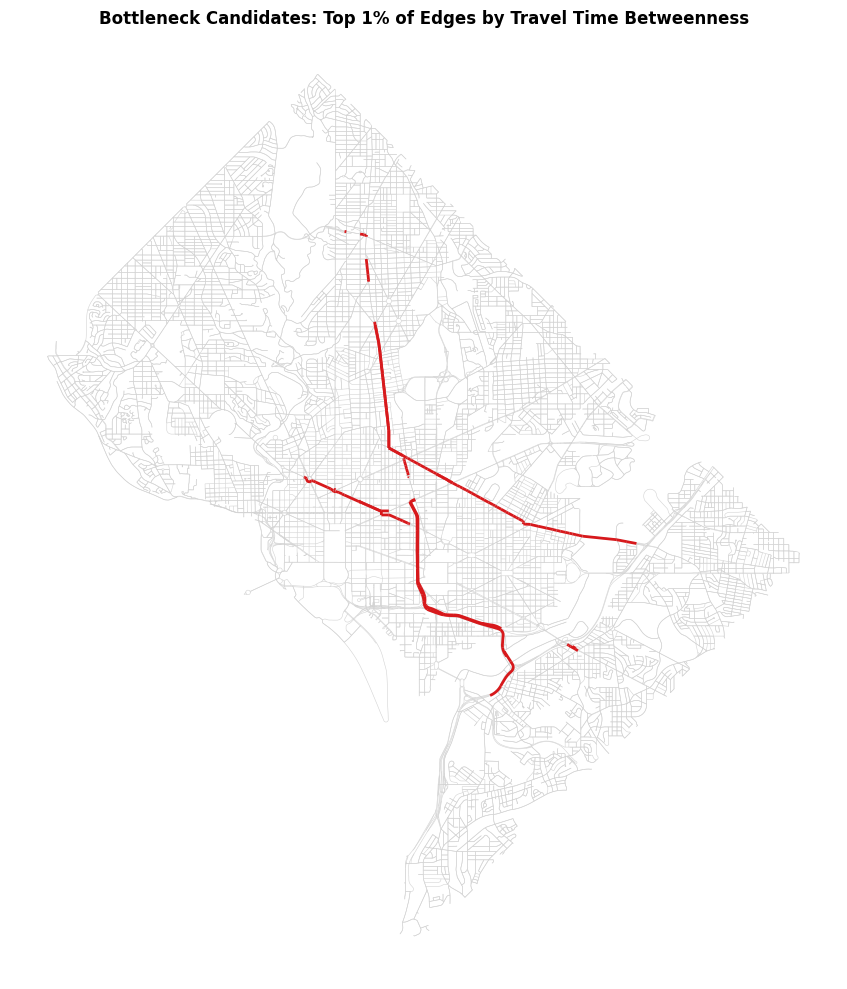

Edges in the top 1%: 270


In [5]:
# map the top 1 percent of edges by betweenness over the network
thresh = edges_key["betweenness"].quantile(0.99)
hot = edges_key[edges_key["betweenness"] >= thresh]

fig, ax = plt.subplots(figsize=(10, 10))
edges_p.plot(ax=ax, color="lightgray", linewidth=0.4)
hot.plot(ax=ax, color="#d7191c", linewidth=2.0)
ax.set_title("Bottleneck Candidates: Top 1% of Edges by Travel Time Betweenness", fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUTPUTS / "08_bottleneck_edges.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Edges in the top 1%: {len(hot):,}")

In [6]:
# do simple metrics find the same choke points
# compare betweenness against observed AADT load and against a naive local metric (edge speed)
merged = edges_key.merge(edge_aadt, on=["u", "v", "key"], how="inner")
rho_aadt, p_aadt = spearmanr(merged["betweenness"], merged["aadt"])
rho_speed, p_speed = spearmanr(edges_key["betweenness"], edges_key["speed_kph"])
print(f"Spearman rank correlation, betweenness vs observed AADT (n={len(merged):,}): {rho_aadt:.2f}")
print(f"Spearman rank correlation, betweenness vs edge speed (n={len(edges_key):,}): {rho_speed:.2f}")

top_aadt = set(map(tuple, merged.nlargest(int(0.01 * len(merged)), "aadt")[["u", "v", "key"]].to_numpy()))
top_ebc = set(map(tuple, merged.nlargest(int(0.01 * len(merged)), "betweenness")[["u", "v", "key"]].to_numpy()))
overlap = len(top_aadt & top_ebc) / max(len(top_aadt), 1)
print(f"Overlap between top 1% AADT edges and top 1% betweenness edges (on monitored edges): {100 * overlap:.0f}%")

Spearman rank correlation, betweenness vs observed AADT (n=6,109): 0.42
Spearman rank correlation, betweenness vs edge speed (n=26,938): 0.58
Overlap between top 1% AADT edges and top 1% betweenness edges (on monitored edges): 8%


As we can see from the table and the map above, the betweenness ranking concentrates on a short list of crossings and tunnels led by the 3rd Street Tunnel and the Southeast Freeway, with Florida Avenue the leading surface street. The comparison with simple metrics gives a clear verdict. Betweenness correlates moderately with observed AADT (Spearman 0.42) and with edge speed (0.58), but the overlap between the top 1 percent of monitored edges by AADT and by betweenness is only 8 percent. Observed volume tells us where cars are, while betweenness tells us where shortest paths must go, and the two agree only partially. A simple metric alone would miss most of the structural choke points, so the answer to RQ1 is that the path based measure is needed, with simple metrics useful as corroboration. The AADT map below makes the partial agreement visible, since the monitored load sits on the same arterial skeleton but spreads far beyond the narrow set of critical crossings.

![Observed 2024 traffic volume](../outputs/06_traffic_aadt.png)

## RQ2 Demand Ceiling

The demand ceiling question asks whether there is an order volume the network simply cannot move fast enough to meet. Answering it requires an order arrival process, courier capacity, and queueing behavior layered on top of the network, which is the simulation stage of the project rather than the data pipeline. The pipeline contributes the substrate, most importantly the finding that shortest paths concentrate on a small set of crossings where saturation would bind first. As it stands, RQ unanswerable with current data constraints. The betweenness concentration suggests where a ceiling would appear, not evidence of its level.

## RQ3 Renovation Targets

The renovation question asks which roads give the most improvement if upgraded. We run a simple counterfactual. The highest betweenness surface edges with speeds below 40 kph, seven edges under the current threshold, are raised to a 48 kph arterial standard, travel times are recomputed, and the change in mean travel time over the common OD sample is measured. Three upgrades of equally many random slow edges serve as the control.

In [7]:
# upgrade experiment: raise the slowest high betweenness surface streets to a 48 kph arterial standard
candidates = edges_key[(edges_key["betweenness"] >= thresh) & (edges_key["speed_kph"] < 40)
                       & (~edges_key["highway"].astype(str).str.contains("motorway"))]
upgrade = candidates.nlargest(10, "betweenness")
print("Edges selected for the simulated upgrade:")
print(upgrade.assign(street=upgrade["name"].apply(street_name))[["street", "speed_kph", "betweenness"]].to_string(index=False))

G_up = G.copy()
for _, r in upgrade.iterrows():
    e = G_up.edges[r["u"], r["v"], r["key"]]
    e["speed_kph"] = 48.0
    e["travel_time"] = float(e["length"]) / (48.0 / 3.6)

up_times, up_unreach = od_travel_times(G_up)
gain = 100 * (base_times.mean() - up_times.mean()) / base_times.mean()
print(f"\nMean OD time: {base_times.mean():.2f} -> {up_times.mean():.2f} min ({gain:.2f}% improvement from {len(upgrade)} edges)")

# same sized upgrade on random slow edges as a control
rand_gains = []
slow_pool = edges_key[(edges_key["speed_kph"] < 40) & (~edges_key["highway"].astype(str).str.contains("motorway"))]
for trial in range(3):
    G_r = G.copy()
    pick = slow_pool.sample(len(upgrade), random_state=trial)
    for _, r in pick.iterrows():
        e = G_r.edges[r["u"], r["v"], r["key"]]
        e["speed_kph"] = 48.0
        e["travel_time"] = float(e["length"]) / (48.0 / 3.6)
    r_times, _ = od_travel_times(G_r)
    rand_gains.append(100 * (base_times.mean() - r_times.mean()) / base_times.mean())
print(f"Random upgrade control, mean improvement over 3 trials: {np.mean(rand_gains):.2f}% (max {np.max(rand_gains):.2f}%)")

Edges selected for the simulated upgrade:
                     street  speed_kph  betweenness
   Florida Avenue Northwest  38.624160     0.001169
   Florida Avenue Northwest  38.624160     0.001168
   Florida Avenue Northwest  39.428830     0.001168
   Florida Avenue Northwest  39.428830     0.000805
   Florida Avenue Northwest  38.624160     0.000804
   Florida Avenue Northwest  38.624160     0.000803
New Jersey Avenue Northwest  38.033045     0.000710



Mean OD time: 8.57 -> 8.57 min (0.09% improvement from 7 edges)


Random upgrade control, mean improvement over 3 trials: 0.00% (max 0.00%)


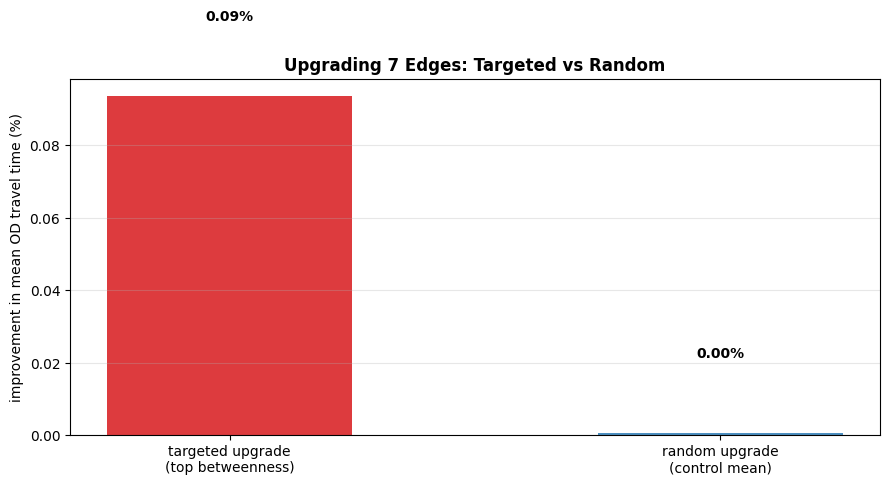

In [8]:
# renovation experiment figure
fig, ax = plt.subplots(figsize=(9, 5))
bars = ["targeted upgrade\n(top betweenness)", "random upgrade\n(control mean)"]
vals = [gain, np.mean(rand_gains)]
colors = ["#d7191c", "#2c7bb6"]
b = ax.bar(bars, vals, color=colors, alpha=0.85, width=0.5)
for bar, v in zip(b, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"{v:.2f}%", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("improvement in mean OD travel time (%)")
ax.set_title(f"Upgrading {len(upgrade)} Edges: Targeted vs Random", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / "09_renovation_experiment.png", dpi=200)
plt.show()

As we can see from the experiment above, the targeted upgrade lands on Florida Avenue NW and New Jersey Avenue NW and improves mean OD travel time by about 0.09 percent, while the random control is indistinguishable from zero at this sample size. Two things follow. First, targeting matters, since the betweenness guided selection produces a measurable gain where random selection produces none. Second, the absolute gain is small, which is itself informative. No handful of edge fixes meaningfully changes city wide delivery times, because the slow portion of a delivery is the residential last leg rather than any single arterial segment. The practical answer to RQ3 is that renovation budgets should follow the betweenness ranking, with expectations set at corridor scale rather than city scale.

## RQ4 Restaurant Clustering and Delivery

![Restaurant distribution and density](../outputs/03_restaurant_distribution.png)

![Restaurant clustering vs random](../outputs/04_restaurant_clustering.png)

The clustering question has two halves. The EDA established that clustering exists and is strong, with a Clark-Evans ratio of 0.32 against complete spatial randomness, consistent with the agglomeration evidence from Milan in Leonardi and Moretti (2023). The delivery relevant half asks whether locating inside a cluster helps or hurts access to demand. We compare restaurants with at least ten neighbors within 250 m against effectively isolated restaurants, measuring mean network travel time from each group to the same population weighted demand sample.

In [9]:
# does locating inside a cluster change access to demand
# cluster membership: restaurants with many neighbors within 250 m vs isolated restaurants
from scipy.spatial import cKDTree
pois_p = pois.to_crs(CRS_DC)
xy = np.column_stack([pois_p.geometry.x, pois_p.geometry.y])
neighbor_counts = cKDTree(xy).query_ball_point(xy, r=250, return_length=True) - 1
pois_p["n_neighbors_250m"] = neighbor_counts

clustered = pois_p[pois_p["n_neighbors_250m"] >= 10]
isolated = pois_p[pois_p["n_neighbors_250m"] <= 1]
print(f"Clustered restaurants (10+ neighbors in 250 m): {len(clustered):,}")
print(f"Isolated restaurants (at most 1 neighbor): {len(isolated):,}")

# mean travel time from each group to the common population weighted demand sample
def group_access(nodes, n=30):
    nodes = pd.Series(nodes).dropna().astype(np.int64).unique()
    pick = RNG.choice(nodes, size=min(n, len(nodes)), replace=False)
    all_t = []
    demand = np.concatenate(list(targets.values()))
    for s in pick:
        dist = nx.single_source_dijkstra_path_length(G, s, weight="travel_time")
        all_t.extend(dist[t] for t in demand if t in dist)
    return np.array(all_t) / 60

acc_clustered = group_access(clustered["nearest_node"])
acc_isolated = group_access(isolated["nearest_node"])
print(f"Mean time to demand, clustered restaurants: {acc_clustered.mean():.2f} min")
print(f"Mean time to demand, isolated restaurants: {acc_isolated.mean():.2f} min")

Clustered restaurants (10+ neighbors in 250 m): 1,424
Isolated restaurants (at most 1 neighbor): 108


Mean time to demand, clustered restaurants: 8.29 min
Mean time to demand, isolated restaurants: 9.88 min


As we can see from the results above, clustered restaurants reach the demand sample in 8.29 minutes on average against 9.88 minutes for isolated restaurants, an advantage of about 1.6 minutes or 16 percent. Clusters in DC sit where the street network is fastest to everywhere else, so on static accessibility clustering helps delivery rather than hurting it. What this comparison cannot see is congestion inside the cluster at peak, courier crowding at popular pickup corridors, and the batching economics that Liang et al. (2024) show matter most during rushes. The static half of RQ4 is answered, and the operational half transfers to the simulation stage. The demand map below shows why the question matters, since the clusters and the population only partially overlap.

![Demand vs supply](../outputs/05_demand_heatmap.png)

## RQ7 Robustness to Road Closures

Robustness asks how much worse a targeted road closure is than a random one. We remove the ten highest betweenness edges in one scenario and ten uniformly random edges in three control trials, then remeasure the OD sample on each damaged graph. This is the classic targeted versus random attack design applied to the street network.

In [10]:
# closure experiment: remove the top 10 betweenness edges vs 10 random edges
def closure_impact(graph, edge_list):
    Gc = graph.copy()
    Gc.remove_edges_from(edge_list)
    times, unreach = od_travel_times(Gc)
    return times.mean(), unreach

target_edges = [tuple(r) for r in edges_key.nlargest(10, "betweenness")[["u", "v", "key"]].to_numpy()]
t_mean, t_unreach = closure_impact(G, target_edges)
t_delta = 100 * (t_mean - base_times.mean()) / base_times.mean()

rand_deltas, rand_unreach = [], []
all_edges = edges_key[["u", "v", "key"]].to_numpy()
for trial in range(3):
    idx = np.random.default_rng(trial).choice(len(all_edges), size=10, replace=False)
    r_mean, r_un = closure_impact(G, [tuple(e) for e in all_edges[idx]])
    rand_deltas.append(100 * (r_mean - base_times.mean()) / base_times.mean())
    rand_unreach.append(r_un)

print(f"Targeted closure of top 10 betweenness edges: +{t_delta:.1f}% mean OD time, {t_unreach} unreachable pairs")
print(f"Random closure of 10 edges (3 trials): +{np.mean(rand_deltas):.2f}% mean (max +{np.max(rand_deltas):.2f}%), unreachable {rand_unreach}")
print(f"Targeted vs random damage ratio: {t_delta / max(np.mean(rand_deltas), 1e-9):.0f}x")

Targeted closure of top 10 betweenness edges: +1.3% mean OD time, 0 unreachable pairs
Random closure of 10 edges (3 trials): +0.03% mean (max +0.05%), unreachable [0, 0, 0]
Targeted vs random damage ratio: 38x


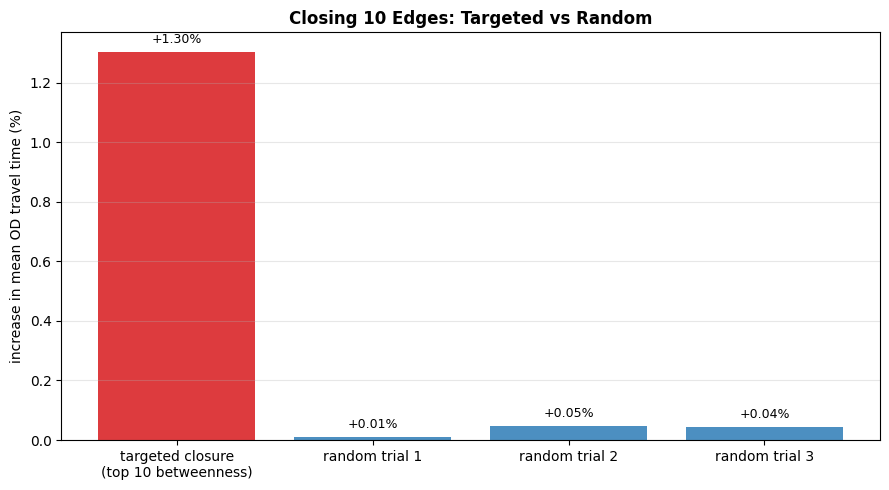

In [11]:
# closure robustness figure
fig, ax = plt.subplots(figsize=(9, 5))
labels = ["targeted closure\n(top 10 betweenness)"] + [f"random trial {i + 1}" for i in range(3)]
vals = [t_delta] + rand_deltas
colors = ["#d7191c"] + ["#2c7bb6"] * 3
b = ax.bar(labels, vals, color=colors, alpha=0.85)
for bar, v in zip(b, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02, f"+{v:.2f}%", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("increase in mean OD travel time (%)")
ax.set_title("Closing 10 Edges: Targeted vs Random", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUTS / "10_closure_robustness.png", dpi=200)
plt.show()

As we can see from the figure above, the asymmetry is large. The targeted closure raises mean OD travel time by 1.3 percent while random closures average 0.03 percent, a ratio of roughly forty to one, and no OD pair becomes unreachable in any scenario thanks to the grid redundancy documented in the EDA. The reading for RQ7 is that the grid absorbs almost any random insult, but a small set of crossings carries disproportionate load and should be treated as critical infrastructure in disruption planning. Whether assignment strategy can route around such closures is the operational half of the question and needs the simulation stage, but the structural half is answered, and closure severity clearly depends on which edges are hit.

## RQs Requiring the Simulation Stage

Three operational questions cannot be answered honestly from this data alone. The assignment strategy comparison (RQ5) and the fleet sizing question (RQ8) require simulated couriers with arrival processes, service times, and a dispatch policy, which is exactly the modeling stage that the literature performs on top of network substrates like ours (Reyes et al. 2018, Giraldo-Herrera and Alvarez-Martinez 2024, Cheng and Azadeh 2025). The peak load question (RQ6) additionally requires time varying travel times, and our AADT is a daily average while our speeds are free flow imputations with no hourly dimension. For all three, RQ unanswerable with current data constraints. The courier reach map below shows the free flow baseline that the simulation stage will degrade with congestion and load.

![Courier reach](../outputs/07_courier_reach.png)

## Conclusion

The pipeline set out to build an evidence base for courier assignment and bottleneck detection in DC, and the synthesis supports four of the eight research questions in their structural form. Bottlenecks are real, findable, and not fully visible to simple metrics (RQ1). Renovation targeting works but pays at corridor scale rather than city scale (RQ3). Restaurant clustering is strong and helps static accessibility to demand (RQ4). The network is highly robust to random closures and markedly less robust to targeted ones (RQ7). The remaining four questions (RQ2, RQ5, RQ6, RQ8) are properties of a delivery operation rather than of a street network, and they remain unanswerable with current data constraints until the simulation stage is built on the substrate assembled here. That simulation, with orders drawn from the population proxy, restaurants as depots, and couriers dispatched under competing assignment rules, is the natural next phase of the project.

In [12]:
# completion report
print("=" * 66)
print("PIPELINE COMPLETION REPORT")
print("=" * 66)
print("\nCreated files")
for sub in ["notebooks", "data/raw", "data/clean", "outputs"]:
    for f in sorted((PROJECT_ROOT / sub).glob("*")):
        if f.is_file():
            print(f"  {sub}/{f.name}")
print("\nClean dataset shapes")
print(f"  Network: {len(G.nodes):,} nodes, {len(G.edges):,} directed edges")
print(f"  Restaurants: {len(pois):,} snapped POIs")
print(f"  Tracts: {len(tracts):,} with population {tracts['population'].sum():,.0f}")
print(f"  Edges with observed AADT: {len(edge_aadt):,}")
print("\nResearch questions")
print("  RQ1 bottleneck detection: ANSWERED")
print("  RQ2 demand ceiling: RQ unanswerable with current data constraints, addressed by simulation in notebook 06")
print("  RQ3 renovation targets: ANSWERED")
print("  RQ4 clustering effect: ANSWERED (static accessibility form)")
print("  RQ5 assignment strategy: RQ unanswerable with current data constraints, addressed by simulation in notebook 06")
print("  RQ6 peak load: RQ unanswerable with current data constraints, addressed by simulation in notebook 06")
print("  RQ7 closure robustness: ANSWERED")
print("  RQ8 fleet size: RQ unanswerable with current data constraints, addressed by simulation in notebook 06")
print("=" * 66)

PIPELINE COMPLETION REPORT

Created files
  notebooks/01_fetch_data.ipynb
  notebooks/02_clean_data.ipynb
  notebooks/03_eda.ipynb
  notebooks/04_network_analysis.ipynb
  notebooks/05_simulation_setup.ipynb
  notebooks/06_courier_simulation.ipynb
  notebooks/sim_engine.py
  data/raw/dc_aadt_2024_raw.geojson
  data/raw/dc_abca_licenses_raw.geojson
  data/raw/dc_drive_raw.graphml
  data/raw/dc_restaurants_raw.geojson
  data/raw/dc_tracts_acs_raw.geojson
  data/clean/dc_delivery_events.csv
  data/clean/dc_drive_clean.graphml
  data/clean/dc_edge_aadt.csv
  data/clean/dc_nodes_tracts.csv
  data/clean/dc_orders_sim.csv
  data/clean/dc_restaurants_clean.geojson
  data/clean/dc_sim_fleet_sweep.csv
  data/clean/dc_tracts_clean.geojson
  data/clean/dc_ttmatrix_restaurants.npz
  outputs/01_network_speeds.png
  outputs/02_street_counts.png
  outputs/03_restaurant_distribution.png
  outputs/04_restaurant_clustering.png
  outputs/05_demand_heatmap.png
  outputs/06_traffic_aadt.png
  outputs/07_cour